# Trabajo Práctico 2: detector de máximo enfoque

Integrantes:
- Lucia T. Capon Paul
- Cesar Orellana
- Leandro Britez

### Objetivo:
Implementar un detector de máximo enfoque sobre un video aplicando técnicas de análisis espectral similar al que utilizan lascámaras digitales modernas. El video a procesar será: “focus_video.mov”.

Se debe implementar un algoritmo que dada una imagen, o región, calcule la métrica propuesta en el paper"Image Sharpness Measure for Blurred Images in Frequency Domain“ y realizar los siguientes experimientos:

1. Medición sobre todo el frame.
2. Medición sobre una ROI ubicada en el centro del frame. Areade la ROI = 5 o 10% del areatotal del frame.
3. Medición sobre una matriz de enfoque compuesta por un arreglo de NxM elementos rectangulares equiespaciados. N y M son valores arbitrarios, probar con varios valores 3x3, 7x5, etc … (al menos 3)
4. Cambiar la métrica de enfoque eligiendo uno de los algoritmos explicados en el apéndice de: Analysis of focus measure operators in shapefrom focus.

In [35]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# 1. Medición Frame completo

In [36]:
# Generamos función que calcula la medida de calidad de la imagen FM 

# La función recibe una imagen en escala de grises y devuelve el valor de FM
# La función sigue los pasos propuestos en el paper "Image Sharpness Measure for Blurred Images in Frequency Domain" 

def calculate_fm(gray_image):

    F = np.fft.fft2(gray_image) # Transformada de Fourier 2D

    Fc = np.fft.fftshift(F) # Desplazar el espectro de frecuencias al centro

    AF = np.abs(Fc) # Magnitud del espectro de frecuencias

    M = np.max(AF) # Valor máximo de la magnitud del espectro de frecuencias

    threshold = M / 1000 # Umbral para considerar una frecuencia como significativa (propuesto en paper)

    TH = np.sum(AF > threshold) # Contar el número de frecuencias significativas

    height, width = gray_image.shape

    FM = TH / (height * width) # Así el resultado no depende del tamaño de imagen

    return FM

Probamos sobre una imagen y validamos contra la misma blurreada, según el procedimiento que utilizan en la paper, esperando que el resultado de la imagen original tenga un resultado mucho mayor. 

In [37]:
img = cv2.imread("guason.png")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

fm = calculate_fm(gray)

print(f"FM = {fm}")

FM = 0.036462673611111114


In [38]:
blurred = cv2.GaussianBlur(gray, (9,9), 0)

fm_original = calculate_fm(gray)
fm_blurred = calculate_fm(blurred)

print("Original:", fm_original)
print("Blurred :", fm_blurred)

Original: 0.036462673611111114
Blurred : 0.01863474151234568


Se convalida la hipóstesis y se procede a trabajar con el vídeo. 

In [39]:
# Función para buscar el máximo enfoque

def detect_max_focus(fm_values):

    max_frame = np.argmax(fm_values)
    max_fm = fm_values[max_frame]

    return max_frame, max_fm

In [40]:
# Realizamos la detección del frame de máximo enfoque

# Abrimos el video
cap = cv2.VideoCapture("focus_video.mov")

fm_values = []
frame_numbers = []

frame_idx = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    fm = calculate_fm(gray)

    fm_values.append(fm)
    frame_numbers.append(frame_idx)

    frame_idx += 1

cap.release()

### Buscar el máximo enfoque

In [41]:
max_frame, max_fm = detect_max_focus(fm_values)

print(f"Frame de máximo enfoque: {max_frame}")
print(f"Valor FM: {max_fm:.6f}")

Frame de máximo enfoque: 109
Valor FM: 0.028242


### Plotear la evolución de enfoque por cada frame

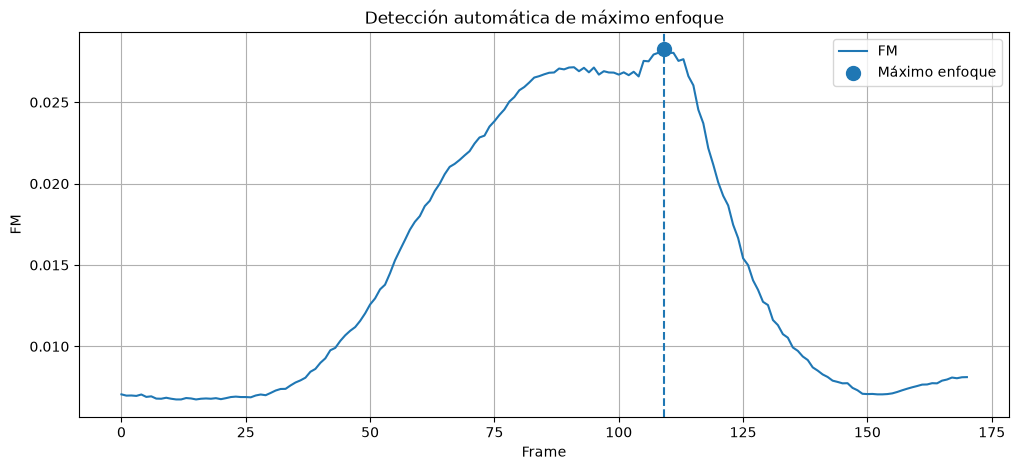

In [42]:
plt.figure(figsize=(12,5))

plt.plot(frame_numbers, fm_values, label="FM")

plt.scatter(
    max_frame,
    max_fm,
    s=100,
    label="Máximo enfoque"
)

plt.axvline(
    max_frame,
    linestyle="--"
)

plt.xlabel("Frame")
plt.ylabel("FM")
plt.title("Detección automática de máximo enfoque")

plt.legend()
plt.grid(True)

plt.show()

## Mostramos el frame de máximo enfoque

In [43]:
cap = cv2.VideoCapture("focus_video.mov")

frame_idx = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    if frame_idx == max_frame:
        best_frame = frame.copy()
        break

    frame_idx += 1

cap.release()

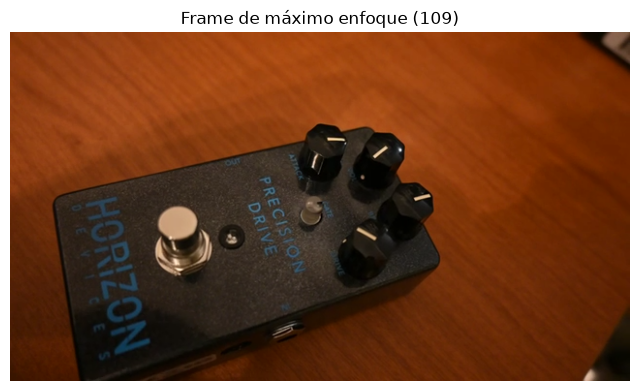

In [44]:
plt.figure(figsize=(8,6))

plt.imshow(cv2.cvtColor(best_frame, cv2.COLOR_BGR2RGB))

plt.title(
    f"Frame de máximo enfoque ({max_frame})"
)

plt.axis("off")

plt.show()

Para cada frame del video se calculó la métrica FM propuesta en el paper. Posteriormente se implementó un detector automático de enfoque máximo, el cual identifica el frame asociado al valor máximo de FM utilizando una búsqueda del máximo global sobre la serie temporal de medidas obtenidas. El algoritmo devuelve automáticamente el número de frame y el valor FM correspondiente al punto de máximo enfoque.

# 2. Medición sobre ROI = 10% 



In [45]:
def get_center_roi(image, roi_percentage=0.10):

    h, w = image.shape[:2]

    scale = np.sqrt(roi_percentage)

    roi_w = int(w * scale)
    roi_h = int(h * scale)

    x1 = (w - roi_w) // 2
    y1 = (h - roi_h) // 2

    x2 = x1 + roi_w
    y2 = y1 + roi_h

    roi = image[y1:y2, x1:x2]

    return roi

Rvisamos si la captura del ROI está centrada y es representativa 

In [46]:
cap = cv2.VideoCapture("focus_video.mov")

ret, frame = cap.read()

cap.release()

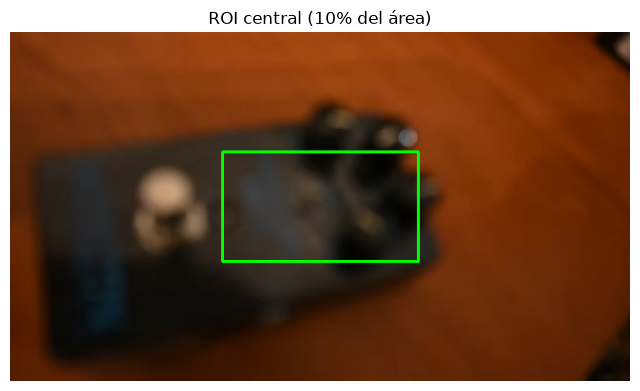

In [47]:
frame_copy = frame.copy()

h, w = frame.shape[:2]

scale = np.sqrt(0.10)

roi_w = int(w * scale)
roi_h = int(h * scale)

x1 = (w - roi_w) // 2
y1 = (h - roi_h) // 2

x2 = x1 + roi_w
y2 = y1 + roi_h

cv2.rectangle(
    frame_copy,
    (x1, y1),
    (x2, y2),
    (0,255,0),
    2
)

plt.figure(figsize=(8,6))

plt.imshow(cv2.cvtColor(frame_copy, cv2.COLOR_BGR2RGB))

plt.title("ROI central (10% del área)")

plt.axis("off")

plt.show()

In [48]:
# Realizamos la detección del frame de máximo enfoque ROI

# Abrimos el video
cap = cv2.VideoCapture("focus_video.mov")

fm_values_roi = []
frame_numbers_roi = []

frame_idx = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    roi = get_center_roi(frame, 0.10) # Extraemos la ROI central (10% del área)

    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

    fm = calculate_fm(gray)

    fm_values_roi.append(fm)
    frame_numbers_roi.append(frame_idx)

    frame_idx += 1

cap.release()

In [49]:
max_frame_roi, max_fm_roi = detect_max_focus(fm_values_roi)

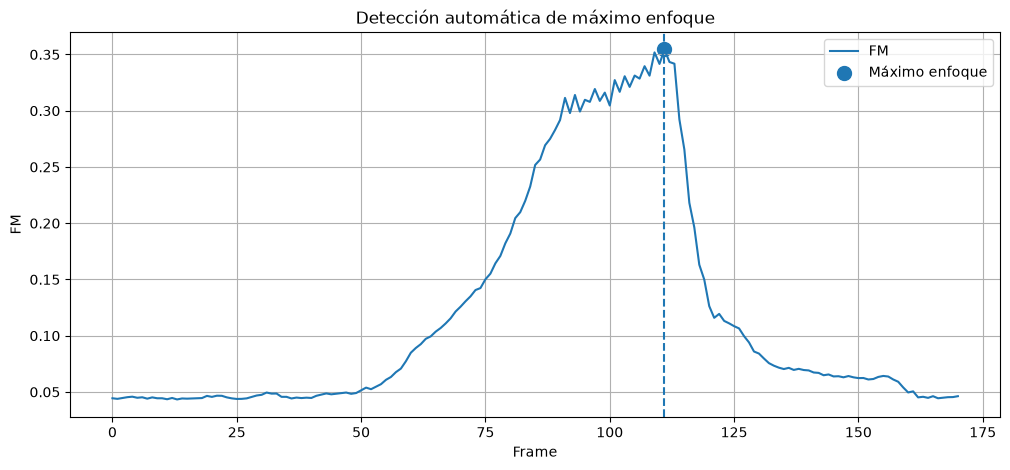

In [50]:
plt.figure(figsize=(12,5))

plt.plot(frame_numbers_roi, fm_values_roi, label="FM")

plt.scatter(
    max_frame_roi,
    max_fm_roi,
    s=100,
    label="Máximo enfoque"
)

plt.axvline(
    max_frame_roi,
    linestyle="--"
)

plt.xlabel("Frame")
plt.ylabel("FM")
plt.title("Detección automática de máximo enfoque")

plt.legend()
plt.grid(True)

plt.show()

# 3. Matriz de enfoque NxM


In [51]:
def split_grid(frame, rows, cols):
    """
    Divide un frame en una grilla rows x cols.

    Returns:
        lista de ROIs
    """

    h, w = frame.shape[:2]

    cell_h = h // rows
    cell_w = w // cols

    rois = []

    for r in range(rows):
        for c in range(cols):

            y1 = r * cell_h
            y2 = (r + 1) * cell_h

            x1 = c * cell_w
            x2 = (c + 1) * cell_w

            roi = frame[y1:y2, x1:x2]

            rois.append(roi)

    return rois

In [52]:
def process_video_grid(
    video_path,
    rows,
    cols,
    focus_function):

    cap = cv2.VideoCapture(video_path)

    frame_idx = 0

    mean_scores = []

    cell_scores = [[] for _ in range(rows * cols)]

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        rois = split_grid(gray, rows, cols)

        current_scores = []

        for i, roi in enumerate(rois):

            fm = focus_function(roi)

            current_scores.append(fm)

            cell_scores[i].append(fm)

        mean_scores.append(np.mean(current_scores))

        frame_idx += 1

    cap.release()

    best_frame = np.argmax(mean_scores)

    return mean_scores, cell_scores, best_frame

In [53]:
def curva_promedio(scores, bests, grilla):
    plt.figure(figsize=(12,6))

    plt.plot(scores)

    plt.axvline(
        bests,
        color='red',
        linestyle='--',
        label=f'Max Focus Frame={bests}'
    )

    plt.title("Métrica Fourier - Grilla "+ grilla)
    plt.xlabel("Frame")
    plt.ylabel("FM")
    plt.legend()
    plt.grid(True)

    plt.show()


def tabla_maximos_roi(cells, rows, cols):

    print(f"\nFrame máximo por ROI ({rows}x{cols})\n")

    matriz = np.zeros((rows, cols), dtype=int)

    idx = 0

    for r in range(rows):
        for c in range(cols):

            matriz[r, c] = np.argmax(cells[idx])

            idx += 1

    print(matriz)

    return matriz


def heatmap_maximos_roi(cells, rows, cols):

    matriz = np.zeros((rows, cols), dtype=int)

    idx = 0

    for r in range(rows):
        for c in range(cols):

            matriz[r, c] = np.argmax(cells[idx])

            idx += 1

    plt.figure(figsize=(6,5))

    plt.imshow(matriz)

    plt.colorbar(label="Frame máximo")

    for r in range(rows):
        for c in range(cols):
            plt.text(
                c,
                r,
                str(matriz[r,c]),
                ha='center',
                va='center'
            )

    plt.title(f"Frame máximo detectado por ROI ({rows}x{cols})")

    plt.show()



def comparar_grillas(
    scores_3x3, best_3x3,
    scores_5x5, best_5x5,
    scores_7x5, best_7x5
):

    plt.figure(figsize=(14,6))

    plt.plot(scores_3x3, label=f'3x3 (max={best_3x3})')
    plt.plot(scores_5x5, label=f'5x5 (max={best_5x5})')
    plt.plot(scores_7x5, label=f'7x5 (max={best_7x5})')

    plt.axvline(best_3x3, linestyle='--')
    plt.axvline(best_5x5, linestyle='--')
    plt.axvline(best_7x5, linestyle='--')

    plt.title("Comparación entre matrices de enfoque")
    plt.xlabel("Frame")
    plt.ylabel("FM promedio")

    plt.grid(True)
    plt.legend()

    plt.show()

### Configuración 3x3

Frame máximo enfoque: 105

Frame máximo por ROI (3x3)

[[ 71  95 123]
 [ 99 103  95]
 [111 108 117]]


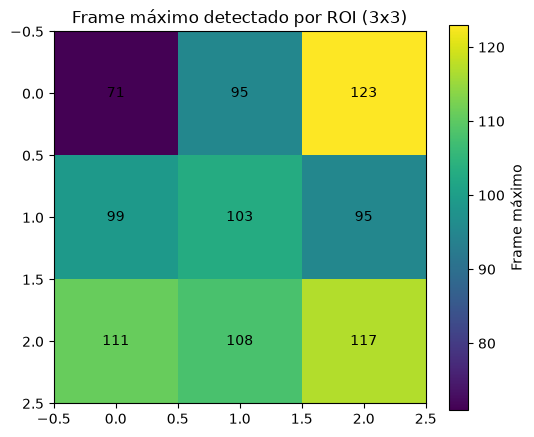

In [56]:
scores_3x3, cells_3x3, best_3x3 = process_video_grid(
    "focus_video.mov",
    rows=3,
    cols=3,
    focus_function=calculate_fm

)

print("Frame máximo enfoque:", best_3x3)
tabla_maximos_roi(cells_3x3, 3, 3)
heatmap_maximos_roi(cells_3x3, 3, 3)

### Configuración 5x5

Frame máximo enfoque: 111

Frame máximo por ROI (5x5)

[[ 69  66  64  61 123]
 [ 75  85  87  93  61]
 [ 99 111 111  97  68]
 [111 111 111 102  74]
 [107 108 107  82 117]]


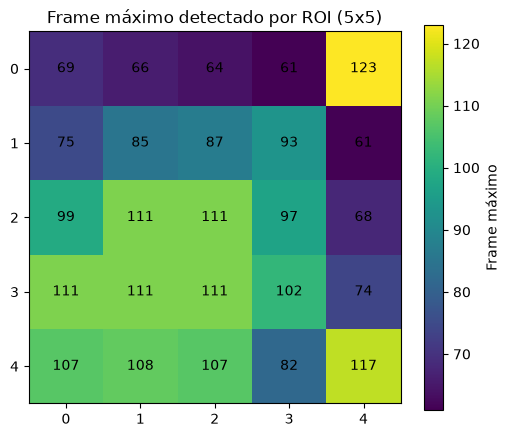

In [57]:
scores_5x5, cells_5x5, best_5x5 = process_video_grid(
    "focus_video.mov",
    rows=5,
    cols=5,
    focus_function=calculate_fm

)

print("Frame máximo enfoque:", best_5x5)

tabla_maximos_roi(cells_5x5, 5, 5)
heatmap_maximos_roi(cells_5x5, 5, 5)

### Configuración 7x5

Frame máximo enfoque: 99

Frame máximo por ROI (7x5)

[[ 69  66  64  61 124]
 [ 69  71  82  62  63]
 [ 79  91  86  87  63]
 [111  99 109  99  64]
 [109 101 103  99  69]
 [101 101 107  79  74]
 [109 110 109  84 119]]


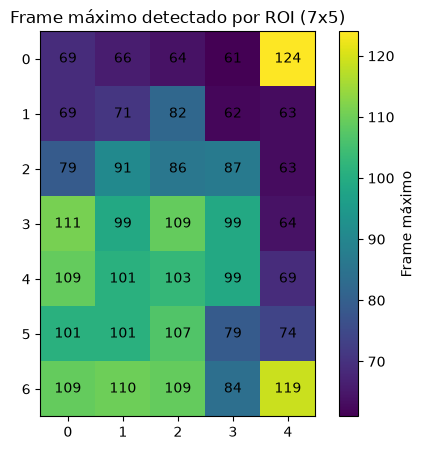

In [58]:
scores_7x5, cells_7x5, best_7x5 = process_video_grid(
    "focus_video.mov",
    rows=7,
    cols=5,
    focus_function=calculate_fm

)

print("Frame máximo enfoque:", best_7x5)

tabla_maximos_roi(cells_7x5, 7, 5)
heatmap_maximos_roi(cells_7x5, 7, 5)

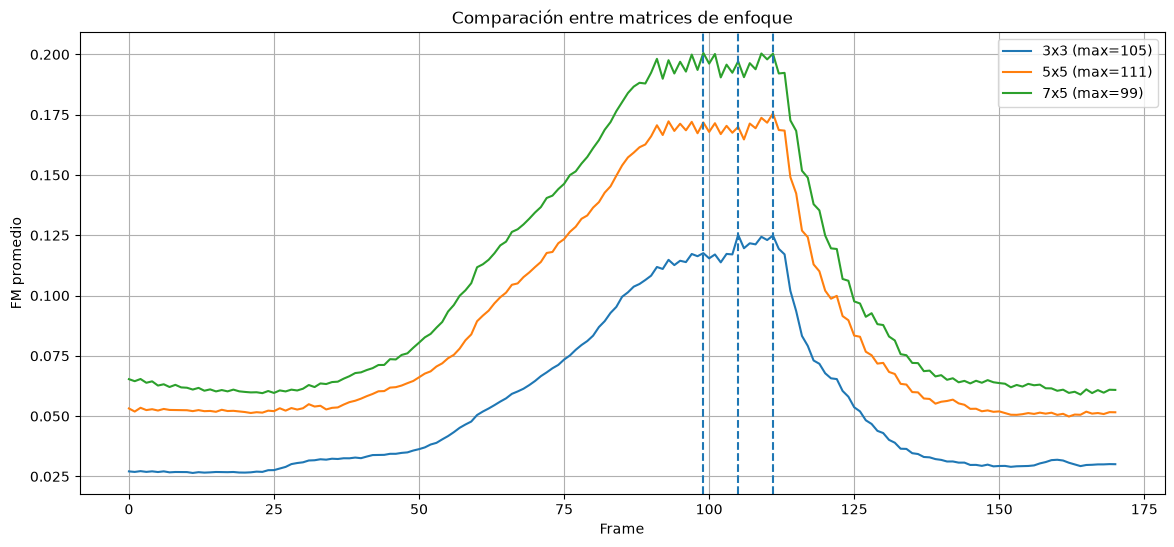

In [59]:
comparar_grillas(
    scores_3x3, best_3x3,
    scores_5x5, best_5x5,
    scores_7x5, best_7x5
)

# 4 Cambio de Algotritmo : Laplacian

Como segunda métrica de enfoque se seleccionó Variance of Laplacian, perteneciente a la familia de operadores basados en derivadas de segundo orden descritos en el paper "Analysis of Focus Measure Operators in Shape From Focus". Esta métrica calcula la varianza de la respuesta del operador Laplaciano sobre la imagen. Las imágenes enfocadas presentan respuestas de mayor amplitud debido a la presencia de bordes más definidos, produciendo valores de varianza más elevados.

In [60]:
def calculate_laplacian_fm(gray):

    lap = cv2.Laplacian(
        gray,
        cv2.CV_64F
    )

    return lap.var()

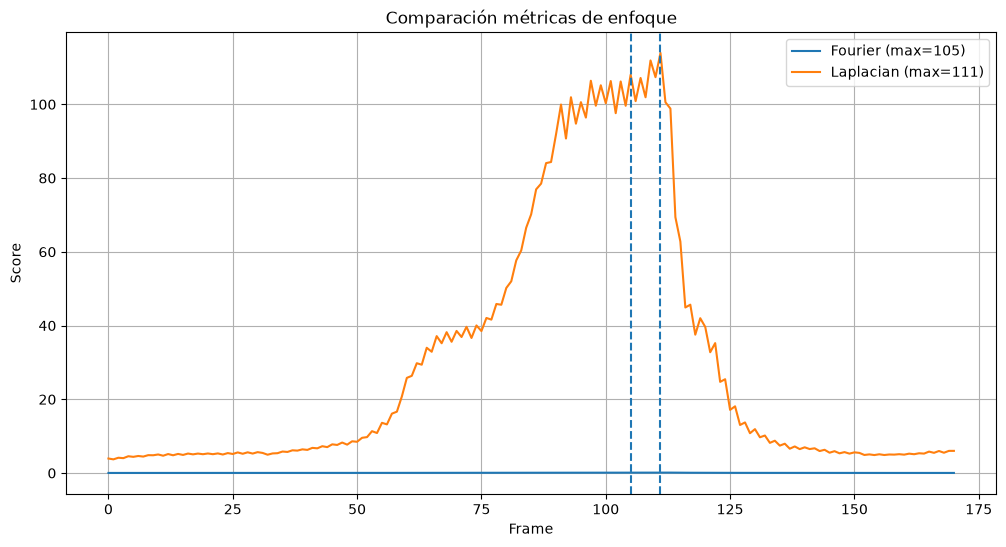

In [61]:
scores_fourier, cells_fourier, best_fourier = (
    process_video_grid(
        "focus_video.mov",
        3,
        3,
        focus_function=calculate_fm

    )
)

scores_lap, cells_lap, best_lap = (
    process_video_grid(
        "focus_video.mov",
        3,
        3,
        focus_function=calculate_laplacian_fm
    )
)

plt.figure(figsize=(12,6))

plt.plot(
    scores_fourier,
    label=f'Fourier (max={best_fourier})'
)

plt.plot(
    scores_lap,
    label=f'Laplacian (max={best_lap})'
)

plt.axvline(best_fourier, linestyle='--')
plt.axvline(best_lap, linestyle='--')

plt.title("Comparación métricas de enfoque")
plt.xlabel("Frame")
plt.ylabel("Score")

plt.grid(True)
plt.legend()

plt.show()

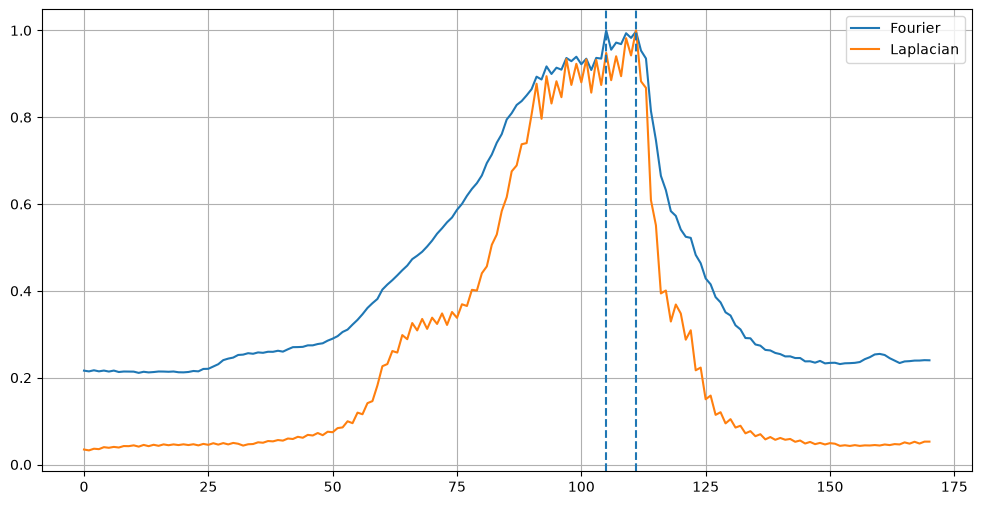

In [62]:
fourier_norm = scores_fourier / np.max(scores_fourier)
lap_norm = scores_lap / np.max(scores_lap)

plt.figure(figsize=(12,6))

plt.plot(fourier_norm, label="Fourier")
plt.plot(lap_norm, label="Laplacian")

plt.axvline(best_fourier, linestyle='--')
plt.axvline(best_lap, linestyle='--')

plt.grid()
plt.legend()
plt.show()

# Resultados y conclusiones

In [63]:
print(
    f"""
=== Experimento 1: Frame completo ===

Máximo enfoque detectado: Frame {max_frame}
Valor FM máximo: {max_fm:.6f}

"""
)

print(
    f"""
=== Experimento 2: ROI central 10% ===

Máximo enfoque detectado: Frame {max_frame_roi}
Valor FM máximo: {max_fm_roi:.6f}

"""
)

print (
    f"""
    === Experimento 3: Matriz de Enfoque N x M ===

3x3 -> frame máximo: {best_3x3}
5x5 -> frame máximo: {best_5x5}
7x5 -> frame máximo: {best_7x5}   
"""
)


print (
    f"""
    === Experimento 4: Cambio de Algortimo - Laplacian ===

Fourier -> frame máximo: {best_fourier}
Laplcacian -> frame máximo: {best_lap}
"""
)


=== Experimento 1: Frame completo ===

Máximo enfoque detectado: Frame 109
Valor FM máximo: 0.028242



=== Experimento 2: ROI central 10% ===

Máximo enfoque detectado: Frame 111
Valor FM máximo: 0.354464



    === Experimento 3: Matriz de Enfoque N x M ===

3x3 -> frame máximo: 105
5x5 -> frame máximo: 111
7x5 -> frame máximo: 99   


    === Experimento 4: Cambio de Algortimo - Laplacian ===

Fourier -> frame máximo: 105
Laplcacian -> frame máximo: 111



Se implementó la métrica FM propuesta en el paper y se utilizó para analizar todos los frames del video con el objetivo de detectar automáticamente el punto de máximo enfoque.

En el primer experimento se calculó la métrica sobre el frame completo. El algoritmo detectó el máximo enfoque en el frame 109 con un valor FM de 0.028624. Luego se repitió el análisis utilizando una ROI central correspondiente al 10% del área de la imagen. En este caso el máximo fue detectado en el frame 111 con un valor FM de 0.357706.

La diferencia entre ambos resultados fue de solamente dos frames, por lo que puede considerarse que ambos métodos encuentran prácticamente la misma región de máximo enfoque. Sin embargo, los valores obtenidos para la ROI fueron considerablemente mayores. Esto se debe a que la medición se realiza únicamente sobre la zona central, donde se encuentra la mayor cantidad de detalles de la escena, evitando que regiones menos relevantes influyan en la métrica.

En el experimento opcional se implementó una matriz de enfoque dividiendo cada frame en regiones rectangulares equiespaciadas. Se probaron configuraciones 3x3, 5x5 y 7x5, calculando la métrica FM en cada región y obteniendo una medida global mediante el promedio de todas ellas.

Los máximos detectados fueron el frame 105 para la configuración 3x3, el frame 111 para la configuración 5x5 y el frame 99 para la configuración 7x5. Aunque los resultados no coinciden exactamente, todos se encuentran dentro de un rango relativamente cercano. Al analizar los máximos obtenidos por cada ROI se observó que las regiones centrales presentan resultados más parecidos entre sí, mientras que las regiones ubicadas en los bordes muestran una mayor variación.

Esto puede explicarse porque las regiones centrales contienen más información útil para evaluar el enfoque, mientras que las regiones periféricas poseen menos detalles o presentan contenido que afecta más a la métrica. Este resultado también ayuda a justificar por qué el experimento realizado sobre una ROI central produjo resultados estables.

Finalmente, se reemplazó la métrica basada en Fourier por una métrica basada en la varianza del Laplaciano (Variance of Laplacian), tomada del paper "Analysis of Focus Measure Operators in Shape From Focus". Utilizando esta nueva métrica, el máximo enfoque fue detectado en el frame 111, mientras que la métrica de Fourier lo detectó en el frame 105.

La diferencia observada entre ambos resultados era esperable, ya que cada método mide características distintas de la imagen. La métrica de Fourier evalúa el contenido frecuencial de la imagen, mientras que el Laplaciano responde principalmente a la presencia de bordes. A pesar de ello, ambos métodos identificaron el máximo enfoque dentro de la misma zona del video, lo que permite concluir que los resultados obtenidos son coherentes y que ambas métricas resultan adecuadas para la detección automática del foco.



